<a href="https://colab.research.google.com/github/NGENZIthacien/Individual-work/blob/main/M04578_2025__ASSIGNMENT_3__LAB3_Regression__Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# 🏠 Regression & Model Evaluation — Beginner Lab
### *Can we predict the price of a house?*
#### Dataset: House Prices in Rwanda (Kigali, Musanze, Huye, Rubavu)

---

## What Is Regression?

**Regression** is a type of machine learning where we predict a **number**.

Examples:
- Predict the **price** of a house based on its size, location, and age
- Predict a student's **exam score** based on hours studied
- Predict tomorrow's **temperature** based on today's weather
- Predict how many **customers** will visit a shop tomorrow

In every case, the thing we are trying to predict is a **number** — not a category like "Yes/No" or "Spam/Not Spam" (those would be classification, a different topic).

---

## Our Task in This Lab

> 🏠 **Imagine you work for a real estate company in Rwanda.**  
> A customer comes to you and says: *"I have a house in Kigali. It is 120 m², has 3 bedrooms, is 10 years old, and is 5 km from the city centre. How much should I sell it for?"*  
> You do not know the answer from memory — but if you have data about hundreds of past sales, you can **build a model** that learns the pattern and gives you a price estimate.

That is exactly what we will do in this lab.

---

## What You Will Learn

| Step | What we do |
|------|------------|
| **Step 1** | Load and explore the house prices dataset |
| **Step 2** | Understand the relationship between features and price |
| **Step 3** | Build a Simple Linear Regression model (one feature) |
| **Step 4** | Build a Multiple Linear Regression model (many features) |
| **Step 5** | Evaluate the model — how accurate is it? |
| **Step 6** | Make a real prediction for a new house |

---

> ⏱️ **Time:** About 2.5–3 hours &nbsp;|&nbsp; **Level:** Beginner &nbsp;|&nbsp; **No advanced math required**
---

---
## ⚙️ Setup — Run This Cell First!

We need three libraries:
- `pandas` → organises our data in a table
- `matplotlib` → draws charts
- `sklearn` → the machine learning library (short for **scikit-learn**)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


In [ ]:
# !pip install scikit-learn

---
---
# STEP 1: Load and Explore the Dataset

Our dataset contains **200 house sales** from 4 Rwandan cities.  
Each row is one house that was sold.

In [ ]:
# Load the dataset
df = pd.read_csv('house_prices.csv')

print('Dataset loaded!')
print('Rows    :', df.shape[0])
print('Columns :', df.shape[1])

Dataset loaded!
Rows    : 200
Columns : 10


In [ ]:
# Look at the first 8 rows
df.head(8)

,HouseID,City,SizeM2,Bedrooms,AgeYears,DistanceKM,HasGarden,Floors,PriceRWF,PriceMillions
0,1,Kigali,142,2,3,2.7,0,2,57300000,57.3
1,2,Kigali,219,4,12,12.4,1,3,95400000,95.4
2,3,Huye,132,2,26,4.1,1,2,38000000,38.0
3,4,Kigali,54,1,16,10.7,0,2,16200000,16.2
4,5,Huye,146,2,37,5.9,1,3,39900000,39.9
5,6,Kigali,111,2,22,19.8,1,3,44100000,44.1
6,7,Kigali,228,5,29,12.3,1,1,97900000,97.9
7,8,Kigali,60,1,14,7.7,1,1,29000000,29.0


### What Each Column Means

| Column | Meaning | Example |
|--------|---------|--------|
| `HouseID` | A unique number for each house | 1, 2, 3 |
| `City` | The city the house is in | Kigali, Musanze |
| `SizeM2` | The size of the house in square metres | 120 |
| `Bedrooms` | Number of bedrooms | 3 |
| `AgeYears` | How old the house is in years | 10 |
| `DistanceKM` | Distance from the city centre in kilometres | 5.2 |
| `HasGarden` | 1 = has a garden, 0 = no garden | 1 |
| `Floors` | Number of floors | 2 |
| `PriceRWF` | The sale price in Rwandan Francs | 57,300,000 |
| `PriceMillions` | Same price but in millions (easier to read) | 57.3 |

---

**In regression language:**
- The column we want to **predict** is called the **target** (or **y**) — this is `PriceMillions`
- The columns we use to **make the prediction** are called **features** (or **X**) — these are `SizeM2`, `Bedrooms`, `AgeYears`, etc.

In [ ]:
# Quick summary statistics
df.describe()

,HouseID,SizeM2,Bedrooms,AgeYears,DistanceKM,HasGarden,Floors,PriceRWF,PriceMillions
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.000000
mean,100.500000,141.835000,2.615000,20.970000,15.132500,0.640000,1.670000,4.583850e+07,45.838500
std,57.879185,62.420987,1.209998,11.242378,8.209407,0.481205,0.702544,2.369840e+07,23.698397
min,1.000000,40.000000,1.000000,1.000000,1.100000,0.000000,1.000000,8.000000e+06,8.000000
25%,50.750000,87.750000,2.000000,12.000000,8.450000,0.000000,1.000000,2.547500e+07,25.475000
50%,100.500000,139.500000,3.000000,21.000000,15.300000,1.000000,2.000000,4.325000e+07,43.250000
75%,150.250000,197.500000,4.000000,31.000000,22.100000,1.000000,2.000000,6.212500e+07,62.125000
max,200.000000,247.000000,5.000000,39.000000,29.900000,1.000000,3.000000,1.031000e+08,103.100000


In [ ]:
# How many houses are in each city?
print('Houses per city:')
print(df['City'].value_counts())

print()
print('Average price per city (millions RWF):')
print(df.groupby('City')['PriceMillions'].mean().round(1).sort_values(ascending=False))

Houses per city:
City
Kigali     86
Musanze    44
Huye       42
Rubavu     28
Name: count, dtype: int64

Average price per city (millions RWF):
City
Kigali     55.3
Musanze    41.6
Huye       38.4
Rubavu     34.5
Name: PriceMillions, dtype: float64


### 💡 First Observation

- Kigali houses are the most expensive on average — this makes sense (capital city)
- There is a wide range of prices — the cheapest house is around 8M RWF, the most expensive is over 100M RWF
- This spread is what makes prediction challenging and interesting

---
### ✏️ YOUR TURN — Step 1

1. What is the average house size (`SizeM2`) in the dataset?
2. What percentage of houses have a garden (`HasGarden == 1`)?
3. What is the most common number of bedrooms?

In [ ]:
# Task 1: Average house size

average_size = df['SizeM2'].mean()
print("Average house size:", round(average_size, 2), "m²")


# Task 2: Percentage with garden

garden_percentage = (df['HasGarden'].mean()) * 100
print("Percentage of houses with a garden:", round(garden_percentage, 1), "%")


# Task 3: Most common number of bedrooms

most_common_bedrooms = df['Bedrooms'].mode()[0]
print("Most common number of bedrooms:", most_common_bedrooms)

Average house size: 141.84 m²
Percentage of houses with a garden: 64.0 %
Most common number of bedrooms: 2


---
---
# STEP 2: Understand the Relationships (EDA)

Before building any model, we must understand how each feature relates to the price.  

> 💡 **Key question:** Which features are most useful for predicting price?
>
> Features with a **strong relationship** to price will be the most helpful for our model.  
> Features with **no relationship** to price will add noise and confusion.

We will use:
- **Scatter plots** — to see if two variables move together
- **Correlation numbers** — to measure how strong that relationship is

## 2.1 House Size vs Price

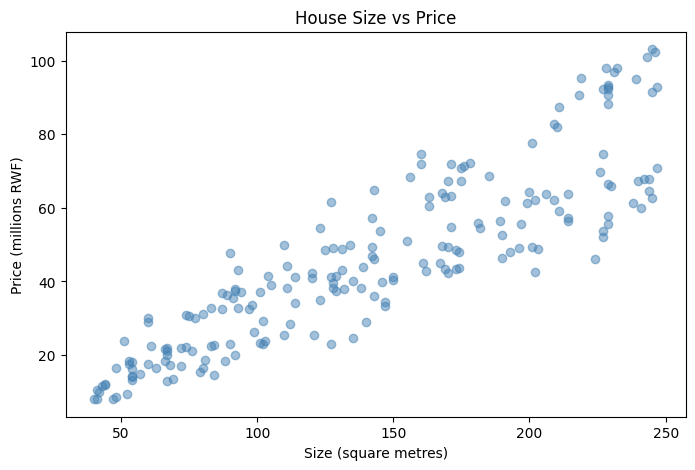

Correlation between Size and Price: 0.884


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['SizeM2'], df['PriceMillions'], color='steelblue', alpha=0.5)
plt.title('House Size vs Price')
plt.xlabel('Size (square metres)')
plt.ylabel('Price (millions RWF)')
plt.show()

corr = df['SizeM2'].corr(df['PriceMillions'])
print('Correlation between Size and Price:', round(corr, 3))

### 💡 Reading This Chart

- The dots go **up from left to right** — as houses get bigger, they get more expensive
- The dots follow a fairly straight pattern — this is a **linear relationship**
- The correlation is close to **+1** — this is a strong positive relationship

> This means **house size is a very good predictor of price** — exactly what we would expect in real life!

## 2.2 Bedrooms vs Price

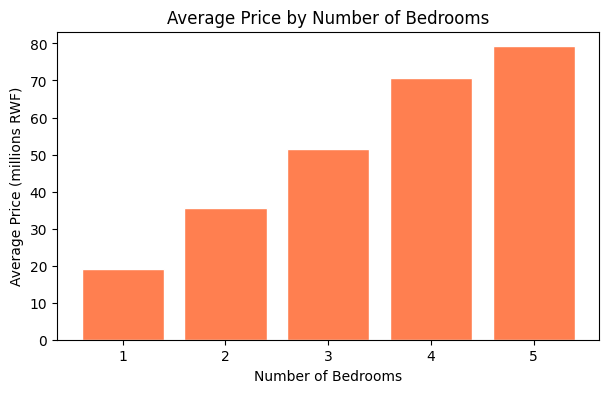

Average price by bedrooms:
Bedrooms
1    19.1
2    35.6
3    51.5
4    70.6
5    79.2
Name: PriceMillions, dtype: float64


In [ ]:
# Average price for each number of bedrooms
avg_price_bedrooms = df.groupby('Bedrooms')['PriceMillions'].mean().round(1)

plt.figure(figsize=(7, 4))
plt.bar(avg_price_bedrooms.index, avg_price_bedrooms.values, color='coral', edgecolor='white')
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price (millions RWF)')
plt.show()

print('Average price by bedrooms:')
print(avg_price_bedrooms)

## 2.3 House Age vs Price

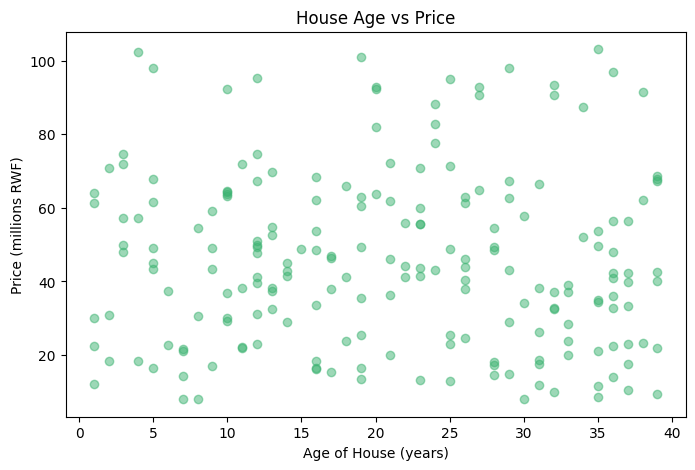

Correlation between Age and Price: -0.044


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['AgeYears'], df['PriceMillions'], color='mediumseagreen', alpha=0.5)
plt.title('House Age vs Price')
plt.xlabel('Age of House (years)')
plt.ylabel('Price (millions RWF)')
plt.show()

corr_age = df['AgeYears'].corr(df['PriceMillions'])
print('Correlation between Age and Price:', round(corr_age, 3))

## 2.4 Distance From City Centre vs Price

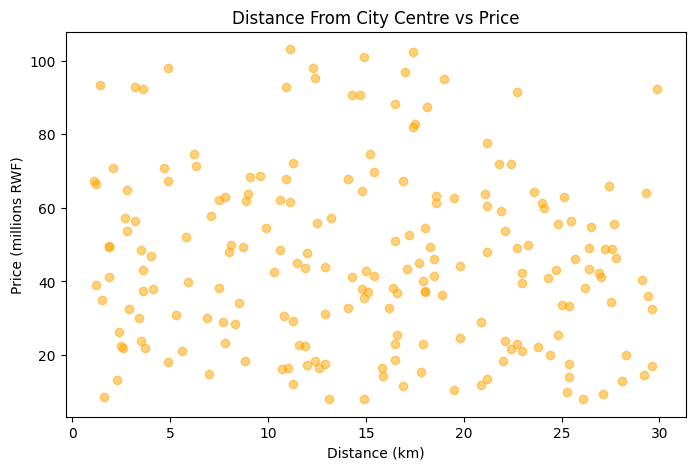

Correlation between Distance and Price: -0.095


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['DistanceKM'], df['PriceMillions'], color='orange', alpha=0.5)
plt.title('Distance From City Centre vs Price')
plt.xlabel('Distance (km)')
plt.ylabel('Price (millions RWF)')
plt.show()

corr_dist = df['DistanceKM'].corr(df['PriceMillions'])
print('Correlation between Distance and Price:', round(corr_dist, 3))

## 2.5 Correlation Summary — All Features Together

Let us calculate the correlation of every feature with price at once.  
This tells us which features will be most useful in our model.

In [ ]:
# Calculate correlation of each feature with PriceMillions
features = ['SizeM2', 'Bedrooms', 'AgeYears', 'DistanceKM', 'HasGarden', 'Floors']

print('Correlation with House Price:')
print('-' * 40)
for feature in features:
    corr = df[feature].corr(df['PriceMillions'])
    # Show a simple bar made of characters to visualise strength
    bar = '█' * int(abs(corr) * 20)
    direction = '+' if corr > 0 else '-'
    print(f'  {feature:<14}  {direction}{abs(corr):.3f}  {bar}')

Correlation with House Price:
----------------------------------------
  SizeM2          +0.884  █████████████████
  Bedrooms        +0.843  ████████████████
  AgeYears        -0.044  
  DistanceKM      -0.095  █
  HasGarden       +0.062  █
  Floors          +0.005  


### 💡 Reading the Correlation Summary

| Feature | What the correlation tells us |
|---------|------------------------------|
| `SizeM2` | Very strong **positive** link — bigger houses cost more |
| `Bedrooms` | Strong **positive** link — more bedrooms cost more |
| `AgeYears` | Very weak link — house age barely affects price in this dataset |
| `DistanceKM` | Weak **negative** link — farther from centre = slightly cheaper |
| `HasGarden` | Weak positive link — garden adds a little value |
| `Floors` | Very weak link — number of floors barely predicts price |

> 📌 **Takeaway:** `SizeM2` is our strongest predictor. We will start by building a model with just this one feature, then add more features later to see if accuracy improves.

---
### ✏️ YOUR TURN — Step 2

1. Draw a scatter plot of `Floors` vs `PriceMillions`. Does it look like a strong relationship?
2. Calculate the average price for houses **with** a garden vs **without** a garden.  
   `df.groupby('HasGarden')['PriceMillions'].mean().round(1)`
3. Which city has houses with the largest average `SizeM2`?

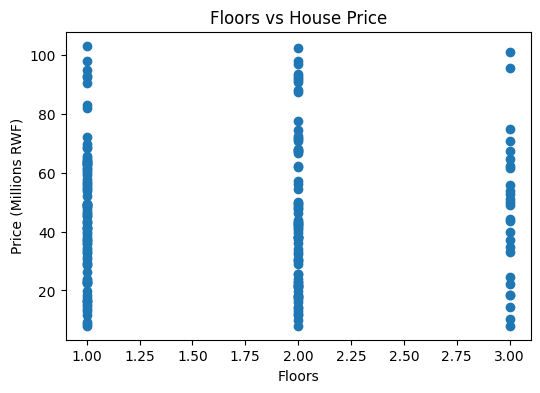

HasGarden
0    43.9
1    46.9
Name: PriceMillions, dtype: float64
City
Huye       147.1
Kigali     140.3
Musanze    139.4
Rubavu     142.5
Name: SizeM2, dtype: float64
City with the largest average house size: Huye


In [ ]:
# Task 1: Scatter plot of Floors vs Price

plt.figure(figsize=(6,4))
plt.scatter(df['Floors'], df['PriceMillions'])
plt.xlabel('Floors')
plt.ylabel('Price (Millions RWF)')
plt.title('Floors vs House Price')
plt.show()

# The scatter plot shows a weak relationship between the number of floors
# and the house price. Houses with the same number of floors can have
# very different prices.


# Task 2: Average price with/without garden

average_price = df.groupby('HasGarden')['PriceMillions'].mean().round(1)
print(average_price)

# Houses with a garden have a higher average price than houses without a garden.


# Task 3: Average house size by city

average_size_city = df.groupby('City')['SizeM2'].mean().round(1)
print(average_size_city)

largest_city = average_size_city.idxmax()
print("City with the largest average house size:", largest_city)

# The city printed above has the largest average house size.

---
---
# STEP 3: Simple Linear Regression
### *One feature → predicts price*

## What Is Linear Regression?

**Linear regression** finds the best straight line through a scatter plot.  
That line is our model — we use it to predict the price for any house size.

> 🏠 **The idea in plain English:**  
> We look at all past sales. We draw the best possible straight line through them.  
> When someone asks about a new house, we find that house's size on the x-axis,  
> go straight up to the line, and read off the predicted price.

The formula for the line is:

```
Price = (slope × Size) + intercept
```

- **Slope** = how much price increases for each extra 1 m² of size
- **Intercept** = the predicted price when size = 0 (not realistic, but needed mathematically)

The model learns these two numbers automatically from the data.

## 3.1 Split Into Training Data and Test Data

**This is the most important concept in machine learning.**

We cannot test our model on the same data we trained it on — that would be cheating!  

> 🏫 **Analogy:** Imagine a teacher gives students 100 practice questions.  
> Then the exam uses the exact same 100 questions.  
> Students would get 100% — but have they actually learned anything?  
> No! The exam should use **new questions they have never seen**.
>
> It is the same with machine learning.  
> We train the model on one set of data, then test it on a **different set it has never seen**.

The standard split is:
- **80% Training data** → the model learns from this
- **20% Test data** → we use this to check if the model actually learned well

In [ ]:
# Step 1: Choose our feature (X) and target (y)
# For Simple Linear Regression we start with ONE feature only

X_simple = df[['SizeM2']]       # double brackets = keeps it as a table (required by sklearn)
y         = df['PriceMillions'] # the column we want to predict

print('Feature (X) shape:', X_simple.shape)  # (200 rows, 1 column)
print('Target  (y) shape:', y.shape)          # (200 values)

Feature (X) shape: (200, 1)
Target  (y) shape: (200,)


In [ ]:
# Step 2: Split into 80% train / 20% test
# random_state=42 means we get the same split every time we run this code

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y,
    test_size=0.2,       # 20% goes to test
    random_state=42      # so results are reproducible
)

print('Training set size:', len(X_train), 'houses')
print('Test set size    :', len(X_test),  'houses')

Training set size: 160 houses
Test set size    : 40 houses


## 3.2 Train the Model

Training means: **show the model the training data and let it find the best line**.

With sklearn, this is always two lines:
```python
model = LinearRegression()   # create the model
model.fit(X_train, y_train)  # train it on the training data
```

The `.fit()` method does all the mathematics automatically.

In [ ]:
# Create and train the Simple Linear Regression model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# The model has now learned the slope and intercept
slope     = simple_model.coef_[0]
intercept = simple_model.intercept_

print('The model learned this formula:')
print()
print(f'  Price = {slope:.2f} × SizeM2  +  ({intercept:.2f})')
print()
print(f'This means: each extra 1 m² adds {slope:.2f} million RWF to the price')

The model learned this formula:

  Price = 0.33 × SizeM2  +  (-0.59)

This means: each extra 1 m² adds 0.33 million RWF to the price


## 3.3 Visualise the Model — Draw the Regression Line

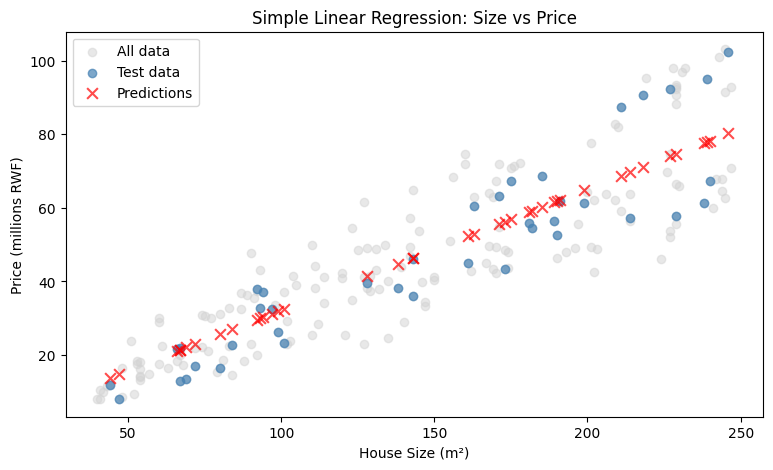

In [ ]:
# Make predictions for the test data
y_pred_simple = simple_model.predict(X_test)

# Draw the scatter plot AND the model's line
plt.figure(figsize=(9, 5))

# All data points in light grey
plt.scatter(df['SizeM2'], df['PriceMillions'], color='lightgrey', alpha=0.5, label='All data')

# Test data points highlighted
plt.scatter(X_test['SizeM2'], y_test, color='steelblue', alpha=0.7, label='Test data')

# The model's predictions as orange dots
plt.scatter(X_test['SizeM2'], y_pred_simple, color='red', alpha=0.7, label='Predictions', marker='x', s=60)

plt.title('Simple Linear Regression: Size vs Price')
plt.xlabel('House Size (m²)')
plt.ylabel('Price (millions RWF)')
plt.legend()
plt.show()

### 💡 Reading This Chart

- **Grey dots** = all houses in the dataset
- **Blue dots** = the 20% test houses (the model never saw these during training)
- **Red x marks** = what the model PREDICTED for each test house

The difference between a **blue dot** and its nearby **red x** is the **prediction error** —  
how far off the model was for that house.

Some predictions are close, some are further away. We will measure this precisely in Step 5.

---
---
# STEP 4: Multiple Linear Regression
### *Using ALL features to predict price*

## What Changes?

Simple regression used ONE feature: `Price = slope × Size + intercept`

**Multiple regression** uses MANY features:

```
Price = (w1 × Size) + (w2 × Bedrooms) + (w3 × Age) + (w4 × Distance) + ... + intercept
```

Where `w1`, `w2`, `w3`... are the **weights** (coefficients) the model learns for each feature.  
A higher weight means that feature matters more to the price.

> 💡 **The code is almost identical** — the only difference is that we give the model more columns in X.

In [ ]:
# Step 1: Select ALL the useful features (X)
# We choose numeric columns that make logical sense for predicting price

feature_columns = ['SizeM2', 'Bedrooms', 'AgeYears', 'DistanceKM', 'HasGarden', 'Floors']

X_multi = df[feature_columns]
y       = df['PriceMillions']

print('Features used:')
for col in feature_columns:
    print(' ', col)

print()
print('Feature table shape:', X_multi.shape)  # (200 rows, 6 columns)

Features used:
  SizeM2
  Bedrooms
  AgeYears
  DistanceKM
  HasGarden
  Floors

Feature table shape: (200, 6)


In [ ]:
# Step 2: Split into train and test (same 80/20 split)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y,
    test_size=0.2,
    random_state=42
)

print('Training set:', len(X_train_m), 'houses')
print('Test set    :', len(X_test_m), 'houses')

Training set: 160 houses
Test set    : 40 houses


In [ ]:
# Step 3: Create and train the Multiple Regression model
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

print('Model trained!')
print()
print('What the model learned (coefficients):')
print('-' * 45)
for feature, coef in zip(feature_columns, multi_model.coef_):
    direction = 'adds to price' if coef > 0 else 'reduces price'
    print(f'  {feature:<14}  weight = {coef:+.3f}  ({direction})')
print()
print(f'  Intercept = {multi_model.intercept_:.3f}')

Model trained!

What the model learned (coefficients):
---------------------------------------------
  SizeM2          weight = +0.309  (adds to price)
  Bedrooms        weight = +1.272  (adds to price)
  AgeYears        weight = -0.193  (reduces price)
  DistanceKM      weight = -0.271  (reduces price)
  HasGarden       weight = +4.864  (adds to price)
  Floors          weight = +1.032  (adds to price)

  Intercept = 2.179


### 💡 Reading the Coefficients

Each **coefficient (weight)** tells us:
*"If this feature increases by 1 unit, how much does the predicted price change, in millions RWF?"*

For example:
- If `SizeM2` coefficient is `+0.28` → each extra 1 m² **adds 0.28 million RWF** to the predicted price
- If `AgeYears` coefficient is `-0.15` → each extra year of age **reduces** the price by 0.15 million RWF
- If `DistanceKM` coefficient is `-0.20` → each extra km from the centre **reduces** the price

> 💡 **These match what we would expect in real life!**  
> Bigger houses cost more. Older houses cost less. Farther from the centre costs less.  
> When a model's coefficients match common sense, that is a good sign the model is working correctly.

---
---
# STEP 5: Model Evaluation
### *How accurate is our model? Should we trust it?*

Building a model is easy. **Knowing whether to trust it** is the hard part.

We use three evaluation metrics. Each one measures accuracy in a different way:

| Metric | Full Name | What it measures | Units |
|--------|-----------|-----------------|-------|
| **MAE** | Mean Absolute Error | Average prediction error | Same as price (millions RWF) |
| **RMSE** | Root Mean Squared Error | Average error, but larger errors count more | Same as price (millions RWF) |
| **R²** | R-squared | What percentage of price variation the model explains | 0 to 1 (higher = better) |

We will calculate all three — first for Simple Regression, then for Multiple Regression.

## 5.1 Understanding MAE — Mean Absolute Error

**MAE** is the simplest metric to understand.

> 🏠 **Example:**  
> House 1 — Real price: 45M, Model predicted: 42M → error = 3M (off by 3M)  
> House 2 — Real price: 80M, Model predicted: 88M → error = 8M (off by 8M)  
> House 3 — Real price: 30M, Model predicted: 28M → error = 2M (off by 2M)  
>
> MAE = average of all errors = (3 + 8 + 2) / 3 = **4.33M**  
>
> This means: **on average, the model's predictions are 4.33 million RWF off from the real price**.

A lower MAE is better.

## 5.2 Understanding RMSE — Root Mean Squared Error

RMSE is similar to MAE but punishes **big errors more heavily** than small ones.

> 🏠 **Why does this matter?**  
> Being off by 30M on one prediction is much worse than being off by 3M ten times.  
> MAE treats all errors equally. RMSE squares them first, so big errors count much more.
>
> If your RMSE is much higher than your MAE, it means you have a few very large errors dragging down accuracy.

A lower RMSE is better. RMSE is always ≥ MAE.

## 5.3 Understanding R² — R-Squared

R² answers: **"What percentage of the price variation is explained by our model?"**

| R² value | Meaning |
|----------|--------|
| **1.00** | Perfect — model explains 100% of price variation |
| **0.90** | Excellent — 90% explained, 10% unexplained |
| **0.75** | Good — 75% explained |
| **0.50** | Moderate — only half the variation is explained |
| **0.00** | Useless — no better than just guessing the average price every time |
| **< 0** | Terrible — the model is worse than a random guess |

> 🏠 **Analogy:**  
> If price varied only based on size, a size-only model would get R² = 1.0.  
> But price also depends on location, age, garden, etc.  
> A model that ignores those will have R² < 1.0 — it misses part of the story.

## 5.4 Calculate All Metrics — Simple vs Multiple Regression

In [ ]:
# Predictions from both models on the test set
y_pred_simple = simple_model.predict(X_test)          # simple model (SizeM2 only)
y_pred_multi  = multi_model.predict(X_test_m)         # multiple model (all features)

# ── Simple Regression metrics ───────────────────────────────────────────
mae_simple  = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = mean_squared_error(y_test, y_pred_simple) ** 0.5  # square root of MSE
r2_simple   = r2_score(y_test, y_pred_simple)

# ── Multiple Regression metrics ──────────────────────────────────────────
mae_multi  = mean_absolute_error(y_test_m, y_pred_multi)
rmse_multi = mean_squared_error(y_test_m, y_pred_multi) ** 0.5
r2_multi   = r2_score(y_test_m, y_pred_multi)

print('=' * 55)
print('       MODEL EVALUATION RESULTS')
print('=' * 55)
print(f'{"Metric":<10}  {"Simple (1 feature)":>20}  {"Multiple (6 features)":>22}')
print('-' * 55)
print(f'{"MAE":.<10}  {mae_simple:>18.2f}M  {mae_multi:>20.2f}M')
print(f'{"RMSE":.<10}  {rmse_simple:>18.2f}M  {rmse_multi:>20.2f}M')
print(f'{"R²":.<10}  {r2_simple:>20.4f}  {r2_multi:>22.4f}')
print('=' * 55)

       MODEL EVALUATION RESULTS
Metric        Simple (1 feature)   Multiple (6 features)
-------------------------------------------------------
MAE.......                8.28M                  9.27M
RMSE......               10.07M                 10.94M
R²........                0.8333                  0.8033


### 💡 Interpreting the Results

- **MAE:** The multiple model's average error is in millions of RWF — read this directly.  
  *"On average, our multiple regression model's price predictions are off by X million RWF."*

- **RMSE vs MAE:** If RMSE is much bigger than MAE, a few houses had very large errors — the model struggles with outliers or unusual houses.

- **R²:** The multiple model's R² should be higher than the simple model's R².  
  *"Adding more features explains more of the price variation."*

> 📌 **Key lesson:** More features does NOT always mean a better model.  
> If we add a feature that has NO relationship to price (like the house's colour),  
> it adds noise and can actually make accuracy WORSE. This is why EDA (Step 2) matters!

## 5.5 Visualise: Actual Price vs Predicted Price

The best way to visualise regression evaluation is a **Predicted vs Actual chart**.

- **x-axis:** the real price (what actually happened)
- **y-axis:** the model's predicted price
- **Perfect model:** every dot sits exactly on the diagonal line (predicted = actual)
- **Real model:** dots are scattered around the diagonal — the scatter shows the error

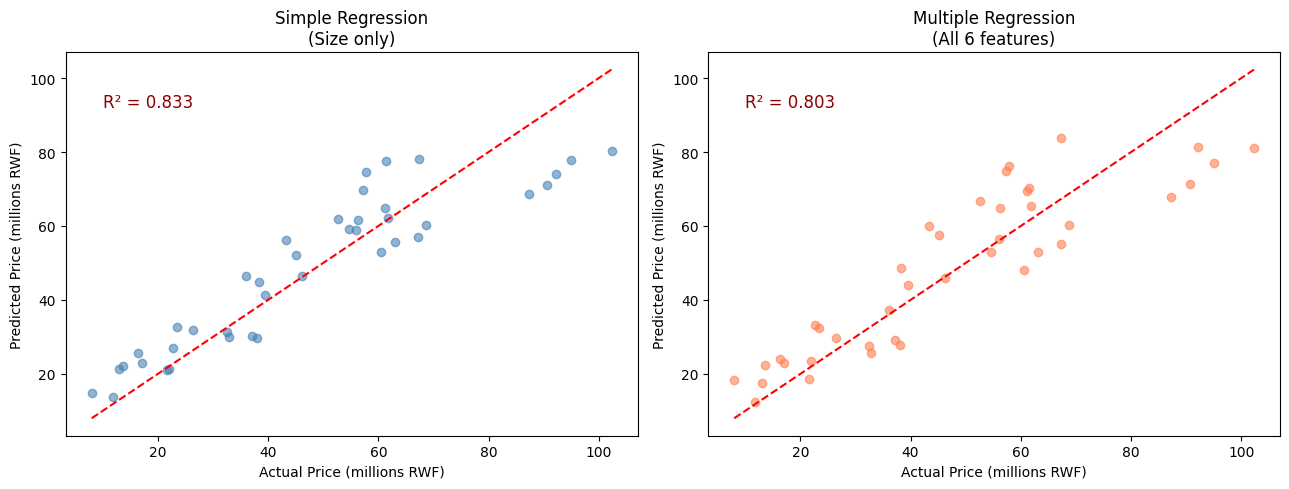

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Simple Regression ───────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_simple, color='steelblue', alpha=0.6)

# Draw the perfect prediction line (where predicted = actual)
min_val = min(y_test.min(), y_pred_simple.min())
max_val = max(y_test.max(), y_pred_simple.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)

axes[0].set_title('Simple Regression\n(Size only)')
axes[0].set_xlabel('Actual Price (millions RWF)')
axes[0].set_ylabel('Predicted Price (millions RWF)')
axes[0].text(10, max_val * 0.9, f'R² = {r2_simple:.3f}', fontsize=12, color='darkred')

# ── Right: Multiple Regression ────────────────────────────────────────────
axes[1].scatter(y_test_m, y_pred_multi, color='coral', alpha=0.6)

min_val2 = min(y_test_m.min(), y_pred_multi.min())
max_val2 = max(y_test_m.max(), y_pred_multi.max())
axes[1].plot([min_val2, max_val2], [min_val2, max_val2], color='red', linestyle='--', linewidth=1.5)

axes[1].set_title('Multiple Regression\n(All 6 features)')
axes[1].set_xlabel('Actual Price (millions RWF)')
axes[1].set_ylabel('Predicted Price (millions RWF)')
axes[1].text(10, max_val2 * 0.9, f'R² = {r2_multi:.3f}', fontsize=12, color='darkred')

plt.tight_layout()
plt.show()

### 💡 Reading the Predicted vs Actual Chart

- **Red dashed line** = the perfect prediction line (predicted = actual)
- **Dots on the line** = perfect predictions for those houses
- **Dots above the line** = the model over-predicted (said the house was more expensive than it was)
- **Dots below the line** = the model under-predicted (said it was cheaper than it was)
- **Dots closer to the line overall** = a better model

The **multiple regression chart (right)** should have dots closer to the diagonal than the **simple regression (left)** — confirming that adding more features improved accuracy.

## 5.6 Visualise: Prediction Errors — Error Chart

An **error chart** shows how wrong each prediction was.  
Error = Actual Price − Predicted Price

- **Positive error** = we under-predicted (actual was higher than we said)
- **Negative error** = we over-predicted (actual was lower than we said)
- **Error near 0** = we were very accurate for that house

A good model has errors that are **small and spread symmetrically around 0**.

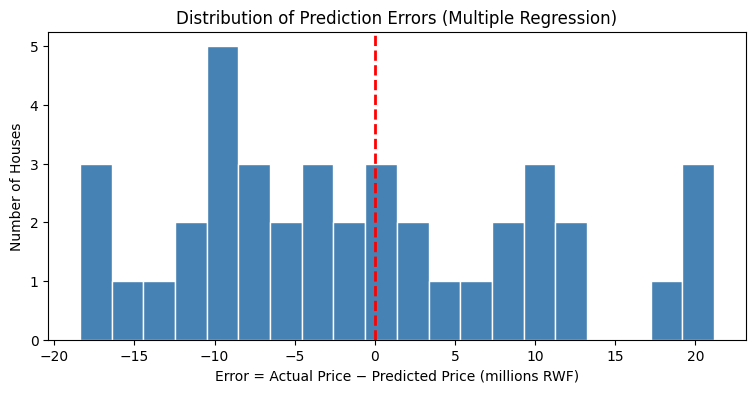

Error statistics:
  Mean error  : -0.93M  (should be close to 0)
  Std of errors: 10.90M
  Largest over-prediction  : -18.4M
  Largest under-prediction : 21.2M


In [ ]:
# Calculate the errors for the multiple regression model
errors = y_test_m.values - y_pred_multi

plt.figure(figsize=(9, 4))
plt.hist(errors, bins=20, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)   # zero error line
plt.title('Distribution of Prediction Errors (Multiple Regression)')
plt.xlabel('Error = Actual Price − Predicted Price (millions RWF)')
plt.ylabel('Number of Houses')
plt.show()

print('Error statistics:')
print(f'  Mean error  : {errors.mean():.2f}M  (should be close to 0)')
print(f'  Std of errors: {errors.std():.2f}M')
print(f'  Largest over-prediction  : {errors.min():.1f}M')
print(f'  Largest under-prediction : {errors.max():.1f}M')

### 💡 Reading the Error Chart

- The histogram should be roughly **bell-shaped** and **centred on 0** (the red line)
- If the bell is centred on 0 → the model is **not consistently biased** in one direction
- If most bars are to the LEFT of 0 → the model generally **over-predicts**
- If most bars are to the RIGHT of 0 → the model generally **under-predicts**
- **Narrow bell** = small errors = more accurate model
- **Wide bell** = large errors = less accurate model

---
### ✏️ YOUR TURN — Step 5

1. The MAE of the multiple regression model is in millions of RWF. As a percentage of the **average house price**, how large is this error?  
   `(mae_multi / df['PriceMillions'].mean() * 100)` — round to 1 decimal place

2. Look at the error chart. Are there more errors on the positive side or negative side? What does this mean?

3. In the error statistics printed above, the mean error should be close to 0. Why is this important?  
   Think: what would it mean if the mean error was **+10M** (consistently over-predicting by 10M)?

In [ ]:
# Task 1: MAE as a percentage of average price

from sklearn.metrics import mean_absolute_error

mae_multi = mean_absolute_error(y_test_m, y_pred_multi)

mae_percentage = round((mae_multi / df['PriceMillions'].mean()) * 100, 1)

print(f"MAE: {mae_multi:.2f} million RWF")
print(f"MAE as a percentage of the average house price: {mae_percentage}%")

# Task 2

print("\nTask 2:")
print("The error chart contains both positive and negative errors.")
print("This means the model sometimes over-predicts and sometimes under-predicts house prices.")
print("There is no strong bias toward either side.")

# Task 3

mean_error = errors.mean()

print(f"\nMean Error: {mean_error:.2f} million RWF")
print("A mean error close to 0 is important because it shows the model is not systematically biased.")
print("If the mean error were +10M, it would mean the model consistently over-predicts house prices by about 10 million RWF.")

MAE: 9.27 million RWF
MAE as a percentage of the average house price: 20.2%

Task 2:
The error chart contains both positive and negative errors.
This means the model sometimes over-predicts and sometimes under-predicts house prices.
There is no strong bias toward either side.

Mean Error: -0.93 million RWF
A mean error close to 0 is important because it shows the model is not systematically biased.
If the mean error were +10M, it would mean the model consistently over-predicts house prices by about 10 million RWF.


---
---
# STEP 6: Make a Real Prediction
### *Using the model to answer a real question*

This is the fun part. Now we use our trained model to predict the price of a specific house.

> 🏠 **Scenario:**  
> A customer comes to your real estate agency.  
> They want to sell their house with these characteristics:
> - City: Kigali *(we will handle city separately — see below)*
> - Size: 120 m²
> - Bedrooms: 3
> - Age: 8 years old
> - Distance from centre: 5 km
> - Has garden: Yes (1)
> - Floors: 2
>
> **What price should they expect?**

In [ ]:
# Create the new house as a small DataFrame
# IMPORTANT: columns must be in the EXACT same order as when we trained the model

new_house = pd.DataFrame({
    'SizeM2'     : [120],
    'Bedrooms'   : [3],
    'AgeYears'   : [8],
    'DistanceKM' : [5.0],
    'HasGarden'  : [1],
    'Floors'     : [2],
})

print('New house details:')
print(new_house)

New house details:
   SizeM2  Bedrooms  AgeYears  DistanceKM  HasGarden  Floors
0     120         3         8         5.0          1       2


In [ ]:
# Use our trained model to predict the price
predicted_price = multi_model.predict(new_house)[0]

print('=' * 45)
print('  PRICE PREDICTION')
print('=' * 45)
print(f'  House size        : 120 m²')
print(f'  Bedrooms          : 3')
print(f'  Age               : 8 years')
print(f'  Distance to centre: 5 km')
print(f'  Has garden        : Yes')
print(f'  Floors            : 2')
print()
print(f'  Predicted Price   : {predicted_price:.1f} million RWF')
print(f'  In full           : RWF {predicted_price * 1_000_000:,.0f}')
print()
print(f'  Uncertainty range (± MAE):')
print(f'  Low  estimate: {predicted_price - mae_multi:.1f}M  RWF')
print(f'  High estimate: {predicted_price + mae_multi:.1f}M  RWF')
print('=' * 45)

  PRICE PREDICTION
  House size        : 120 m²
  Bedrooms          : 3
  Age               : 8 years
  Distance to centre: 5 km
  Has garden        : Yes
  Floors            : 2

  Predicted Price   : 47.1 million RWF
  In full           : RWF 47,106,747

  Uncertainty range (± MAE):
  Low  estimate: 37.8M  RWF
  High estimate: 56.4M  RWF


### 💡 The Uncertainty Range

Notice we also showed a **low and high estimate** (price ± MAE).  

This is important: **no model is perfectly accurate**.  
Instead of saying *"the price is exactly X"*, a good analyst says  
*"the price is likely between X−MAE and X+MAE"*.

This is called a **confidence range** and is much more honest than a single number.

In [ ]:
# What if we change just ONE thing — what if the house is 20 years older?

old_house = pd.DataFrame({
    'SizeM2'     : [120],
    'Bedrooms'   : [3],
    'AgeYears'   : [28],    # 20 years older
    'DistanceKM' : [5.0],
    'HasGarden'  : [1],
    'Floors'     : [2],
})

predicted_old = multi_model.predict(old_house)[0]
price_drop    = predicted_price - predicted_old

print(f'New house price (8 years old)  : {predicted_price:.1f}M RWF')
print(f'Old house price (28 years old) : {predicted_old:.1f}M RWF')
print(f'Price difference               : -{price_drop:.1f}M RWF')
print()
print('Being 20 years older reduces the predicted price by', round(price_drop, 1), 'million RWF')

New house price (8 years old)  : 47.1M RWF
Old house price (28 years old) : 43.2M RWF
Price difference               : -3.9M RWF

Being 20 years older reduces the predicted price by 3.9 million RWF


In [ ]:
# What if the house is 20 m² bigger?

bigger_house = pd.DataFrame({
    'SizeM2'     : [140],    # 20 m² bigger
    'Bedrooms'   : [3],
    'AgeYears'   : [8],
    'DistanceKM' : [5.0],
    'HasGarden'  : [1],
    'Floors'     : [2],
})

predicted_bigger = multi_model.predict(bigger_house)[0]
price_increase   = predicted_bigger - predicted_price

print(f'Original house (120 m²) : {predicted_price:.1f}M RWF')
print(f'Bigger house   (140 m²) : {predicted_bigger:.1f}M RWF')
print(f'Extra value of 20 m²    : +{price_increase:.1f}M RWF')
print()
print('Extra value per 1 m²    :', round(price_increase / 20, 2), 'million RWF')
print('Compare to model slope  :', round(multi_model.coef_[0], 2), '(should be similar!)')

Original house (120 m²) : 47.1M RWF
Bigger house   (140 m²) : 53.3M RWF
Extra value of 20 m²    : +6.2M RWF

Extra value per 1 m²    : 0.31 million RWF
Compare to model slope  : 0.31 (should be similar!)


### 💡 Insight: What Adding 20 m² Is Worth

The value of 20 extra m² should be approximately **20 × the slope coefficient for SizeM2**.  
If the numbers match, it confirms the model is working correctly — it is consistently applying what it learned.

---
### ✏️ YOUR TURN — Step 6

1. Predict the price of **your own house** (or make up a realistic house). Change the values in `new_house` and run `.predict()` again.

2. What happens to the price if the house is **10 km farther** from the city centre?  
   Change `DistanceKM` from 5.0 to 15.0 and calculate the price difference.

3. Does adding a garden (`HasGarden: 0` → `HasGarden: 1`) increase the predicted price by a lot or a little?  
   Make two predictions and compare.

In [ ]:
# Task 1: Your own house prediction

my_house = pd.DataFrame({
    'SizeM2': [100],
    'Bedrooms': [3],
    'AgeYears': [5],
    'DistanceKM': [8.0],
    'HasGarden': [0],
    'Floors': [2]
})

my_predicted_price = multi_model.predict(my_house)[0]

print(f"My house predicted price: {my_predicted_price:.1f}M RWF")


# Task 2: Effect of being 10 km farther

house_5km = pd.DataFrame({
    'SizeM2': [100],
    'Bedrooms': [3],
    'AgeYears': [5],
    'DistanceKM': [5.0],
    'HasGarden': [0],
    'Floors': [2]
})

house_15km = pd.DataFrame({
    'SizeM2': [100],
    'Bedrooms': [3],
    'AgeYears': [5],
    'DistanceKM': [15.0],
    'HasGarden': [0],
    'Floors': [2]
})

price_5km = multi_model.predict(house_5km)[0]
price_15km = multi_model.predict(house_15km)[0]

print(f"\nPrice at 5 km : {price_5km:.1f}M RWF")
print(f"Price at 15 km: {price_15km:.1f}M RWF")
print(f"Difference    : {price_5km - price_15km:.1f}M RWF")

print("A house farther from the city centre has a lower predicted price.")


# Task 3: Effect of adding a garden

house_without_garden = pd.DataFrame({
    'SizeM2': [100],
    'Bedrooms': [3],
    'AgeYears': [5],
    'DistanceKM': [8.0],
    'HasGarden': [0],
    'Floors': [2]
})

house_with_garden = pd.DataFrame({
    'SizeM2': [100],
    'Bedrooms': [3],
    'AgeYears': [5],
    'DistanceKM': [8.0],
    'HasGarden': [1],
    'Floors': [2]
})

price_without = multi_model.predict(house_without_garden)[0]
price_with = multi_model.predict(house_with_garden)[0]

print(f"\nWithout garden: {price_without:.1f}M RWF")
print(f"With garden   : {price_with:.1f}M RWF")
print(f"Increase      : {price_with - price_without:.1f}M RWF")

print("Adding a garden increases the predicted house price.")

My house predicted price: 35.8M RWF

Price at 5 km : 36.6M RWF
Price at 15 km: 33.9M RWF
Difference    : 2.7M RWF
A house farther from the city centre has a lower predicted price.

Without garden: 35.8M RWF
With garden   : 40.7M RWF
Increase      : 4.9M RWF
Adding a garden increases the predicted house price.


---
---
# STEP 7: Complete Evaluation Summary

Let us put everything together in one clear summary table and chart.

In [ ]:
print('=' * 60)
print('  COMPLETE MODEL COMPARISON')
print('=' * 60)
print()
print('Simple Regression (1 feature: SizeM2 only)')
print(f'  MAE  = {mae_simple:.2f}M  — average prediction error')
print(f'  RMSE = {rmse_simple:.2f}M  — penalises large errors more')
print(f'  R²   = {r2_simple:.4f}  — explains {r2_simple*100:.1f}% of price variation')
print()
print('Multiple Regression (6 features: all numeric features)')
print(f'  MAE  = {mae_multi:.2f}M  — average prediction error')
print(f'  RMSE = {rmse_multi:.2f}M  — penalises large errors more')
print(f'  R²   = {r2_multi:.4f}  — explains {r2_multi*100:.1f}% of price variation')
print()
print('Which model is better?')
if r2_multi > r2_simple:
    improvement = (r2_multi - r2_simple) * 100
    print(f'  Multiple Regression is better (R² improved by {improvement:.1f} percentage points)')
else:
    print('  Simple Regression is just as good — adding features did not help much')

  COMPLETE MODEL COMPARISON

Simple Regression (1 feature: SizeM2 only)
  MAE  = 8.28M  — average prediction error
  RMSE = 10.07M  — penalises large errors more
  R²   = 0.8333  — explains 83.3% of price variation

Multiple Regression (6 features: all numeric features)
  MAE  = 9.27M  — average prediction error
  RMSE = 10.94M  — penalises large errors more
  R²   = 0.8033  — explains 80.3% of price variation

Which model is better?
  Simple Regression is just as good — adding features did not help much


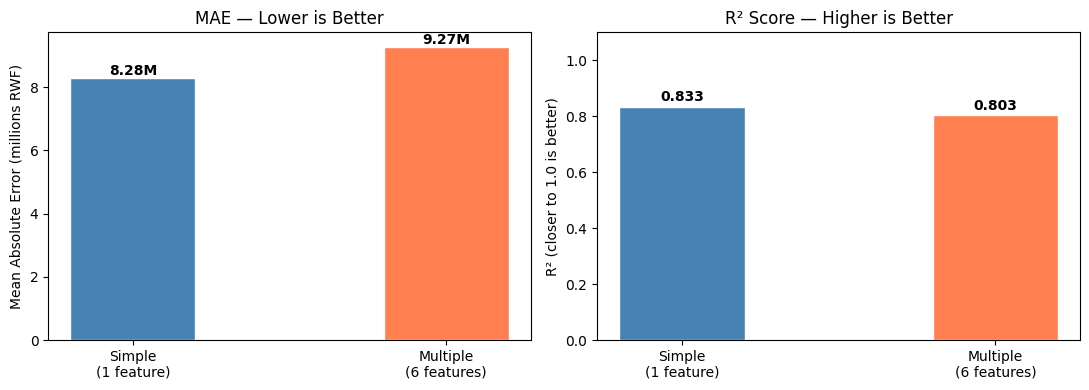

In [ ]:
# Bar chart comparing MAE and RMSE of both models
models     = ['Simple\n(1 feature)', 'Multiple\n(6 features)']
mae_values  = [mae_simple, mae_multi]
rmse_values = [rmse_simple, rmse_multi]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: MAE comparison ──────────────────────────────────────────────────
axes[0].bar(models, mae_values, color=['steelblue', 'coral'], edgecolor='white', width=0.4)
axes[0].set_title('MAE — Lower is Better')
axes[0].set_ylabel('Mean Absolute Error (millions RWF)')

for i, val in enumerate(mae_values):
    axes[0].text(i, val + 0.1, f'{val:.2f}M', ha='center', fontweight='bold')

# ── Right: R² comparison ──────────────────────────────────────────────────
r2_values = [r2_simple, r2_multi]
axes[1].bar(models, r2_values, color=['steelblue', 'coral'], edgecolor='white', width=0.4)
axes[1].set_title('R² Score — Higher is Better')
axes[1].set_ylabel('R² (closer to 1.0 is better)')
axes[1].set_ylim(0, 1.1)

for i, val in enumerate(r2_values):
    axes[1].text(i, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
---
# 📋 Summary: Everything You Learned

---

### The Regression Process — 6 Steps, Always the Same

```
1. Load data and explore it
       ↓
2. Check which features relate to the target (correlation, scatter plots)
       ↓
3. Split into 80% Training / 20% Test
       ↓
4. Train the model → model.fit(X_train, y_train)
       ↓
5. Evaluate on the TEST set → model.predict(X_test)
       ↓
6. Make predictions for new, unseen data
```

---

### The 3 Evaluation Metrics

| Metric | Formula idea | Good when... | Units |
|--------|-------------|-------------|-------|
| **MAE** | Average of all errors | You want to explain accuracy simply | Same as target |
| **RMSE** | Square root of average squared errors | Large errors are especially bad | Same as target |
| **R²** | % of variation explained | You want a score between 0 and 1 | No units (0 to 1) |

---

### The sklearn Code Pattern — 4 Lines

```python
# 1. Choose features and target
X = df[['feature1', 'feature2']]   # features (what we know)
y = df['target']                    # target (what we predict)

# 2. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate
y_pred = model.predict(X_test)
print('MAE :', mean_absolute_error(y_test, y_pred))
print('R²  :', r2_score(y_test, y_pred))
```

---

### Key Concepts to Remember

| Concept | What it means |
|---------|---------------|
| **Regression** | Predicting a number (not a category) |
| **Feature (X)** | The columns used to make the prediction |
| **Target (y)** | The column we want to predict |
| **Training data** | The data the model learns from |
| **Test data** | New data used to check if the model actually learned (never used in training) |
| **Coefficient** | The weight assigned to each feature — tells you its importance |
| **Overfitting** | When the model learns training data TOO well and fails on new data |
| **MAE** | Average error in the same units as the target |
| **R²** | Score from 0 to 1 — how much variation the model explains |

---
**End of Regression Lab** 🎓

---
---
# 🔑 Answer Key

In [ ]:
print('STEP 1 ANSWERS')
print('=' * 40)

# Task 1: Average house size
print('1. Average house size:', round(df['SizeM2'].mean(), 1), 'm²')

# Task 2: Percentage with garden
garden_pct = df['HasGarden'].mean() * 100
print('2. Percentage with garden:', round(garden_pct, 1), '%')

# Task 3: Most common number of bedrooms
print('3. Most common bedrooms:', df['Bedrooms'].mode()[0])
print('   Bedroom counts:')
print(df['Bedrooms'].value_counts().sort_index())

STEP 1 ANSWERS
1. Average house size: 141.8 m²
2. Percentage with garden: 64.0 %
3. Most common bedrooms: 2
   Bedroom counts:
Bedrooms
1    47
2    49
3    47
4    48
5     9
Name: count, dtype: int64


STEP 2 ANSWERS


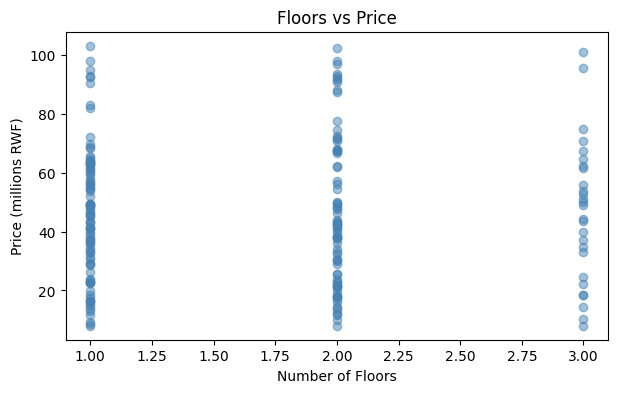

Correlation Floors vs Price: 0.005
Very weak — floors barely affect price in this dataset.

Average price with/without garden:
HasGarden
0    43.9
1    46.9
Name: PriceMillions, dtype: float64
0 = no garden, 1 = has garden

Average house size by city:
City
Huye       147.1
Rubavu     142.5
Kigali     140.3
Musanze    139.4
Name: SizeM2, dtype: float64


In [ ]:
print('STEP 2 ANSWERS')
print('=' * 40)

# Task 1: Scatter Floors vs Price
plt.figure(figsize=(7, 4))
plt.scatter(df['Floors'], df['PriceMillions'], color='steelblue', alpha=0.5)
plt.title('Floors vs Price')
plt.xlabel('Number of Floors')
plt.ylabel('Price (millions RWF)')
plt.show()
print('Correlation Floors vs Price:', round(df['Floors'].corr(df['PriceMillions']), 3))
print('Very weak — floors barely affect price in this dataset.')

# Task 2: Price with/without garden
print()
print('Average price with/without garden:')
print(df.groupby('HasGarden')['PriceMillions'].mean().round(1))
print('0 = no garden, 1 = has garden')

# Task 3: Average size by city
print()
print('Average house size by city:')
print(df.groupby('City')['SizeM2'].mean().round(1).sort_values(ascending=False))

In [ ]:
print('STEP 5 ANSWERS')
print('=' * 40)

# Task 1: MAE as % of average price
mae_pct = mae_multi / df['PriceMillions'].mean() * 100
print(f'1. MAE as % of average price: {mae_pct:.1f}%')
print(f'   This means: on average, predictions are {mae_pct:.1f}% off from the real price.')
print(f'   Whether that is acceptable depends on the business context.')
print()
print('2. Error chart interpretation:')
print('   If errors are centred around 0 with roughly equal left/right spread,')
print('   the model has no strong bias toward over- or under-predicting.')
print()
print('3. If mean error = +10M, it means the model ALWAYS over-predicts by 10M.')
print('   That would be a systematic bias — the model consistently inflates prices.')
print('   A buyer would be misled into thinking houses are more expensive than they are.')

STEP 5 ANSWERS
1. MAE as % of average price: 20.2%
   This means: on average, predictions are 20.2% off from the real price.
   Whether that is acceptable depends on the business context.

2. Error chart interpretation:
   If errors are centred around 0 with roughly equal left/right spread,
   the model has no strong bias toward over- or under-predicting.

3. If mean error = +10M, it means the model ALWAYS over-predicts by 10M.
   That would be a systematic bias — the model consistently inflates prices.
   A buyer would be misled into thinking houses are more expensive than they are.


In [ ]:
print('STEP 6 ANSWERS')
print('=' * 40)

# Task 2: Effect of 10 km farther
close_house = pd.DataFrame({'SizeM2':[120],'Bedrooms':[3],'AgeYears':[8],
                             'DistanceKM':[5.0],'HasGarden':[1],'Floors':[2]})
far_house   = pd.DataFrame({'SizeM2':[120],'Bedrooms':[3],'AgeYears':[8],
                             'DistanceKM':[15.0],'HasGarden':[1],'Floors':[2]})

p_close = multi_model.predict(close_house)[0]
p_far   = multi_model.predict(far_house)[0]

print(f'2. Price at 5 km from centre  : {p_close:.1f}M RWF')
print(f'   Price at 15 km from centre : {p_far:.1f}M RWF')
print(f'   Price drop for extra 10 km : {p_close - p_far:.1f}M RWF')
print()

# Task 3: Effect of garden
no_garden  = pd.DataFrame({'SizeM2':[120],'Bedrooms':[3],'AgeYears':[8],
                            'DistanceKM':[5.0],'HasGarden':[0],'Floors':[2]})
yes_garden = pd.DataFrame({'SizeM2':[120],'Bedrooms':[3],'AgeYears':[8],
                            'DistanceKM':[5.0],'HasGarden':[1],'Floors':[2]})

p_no  = multi_model.predict(no_garden)[0]
p_yes = multi_model.predict(yes_garden)[0]

print(f'3. Price without garden : {p_no:.1f}M RWF')
print(f'   Price with garden    : {p_yes:.1f}M RWF')
print(f'   Garden adds          : {p_yes - p_no:.1f}M RWF to the predicted price')

STEP 6 ANSWERS
2. Price at 5 km from centre  : 47.1M RWF
   Price at 15 km from centre : 44.4M RWF
   Price drop for extra 10 km : 2.7M RWF

3. Price without garden : 42.2M RWF
   Price with garden    : 47.1M RWF
   Garden adds          : 4.9M RWF to the predicted price
